# Exploratory Data Analysis

After cleaning, we can now proceed to EDA using the merged dataset. Importing necessary libraries and obtaining our cleaned dataset:

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

df_cleaned = pd.read_csv("cleaned_data/05_merged_cleaned_dataset.csv")

We will first focus on the columns from each subdataset before finding correlations between each other.

## Labels

We have already established that a neutralizer **is** a binder. Checking class balance:

In [30]:
binding_col = "is_binding_SARS-CoV2_WT"
neutral_col = "is_neutral_SARS-CoV2_WT"

required_cols = [binding_col, neutral_col]
missing_cols = [c for c in required_cols if c not in df_cleaned.columns]
if missing_cols:
    raise KeyError(f"Missing required WT label columns: {missing_cols}")

id_col = "id" if "id" in df_cleaned.columns else None
universe = df_cleaned[id_col] if id_col else df_cleaned.index

binding_set = set(universe[df_cleaned[binding_col] == 1])
neutral_set = set(universe[df_cleaned[neutral_col] == 1])

only_binding = len(binding_set - neutral_set)
only_neutral = len(neutral_set - binding_set)
both = len(binding_set & neutral_set)
neither = len(set(universe) - (binding_set | neutral_set))

print(f"Neutralizer: {both}")
print(f"Binder: {only_binding}")
print(f"Neither: {neither}")
print(f"Total: {len(universe)}")

Neutralizer: 5370
Binder: 2103
Neither: 5212
Total: 12685


For each class of Neutralizer, Binder or Neither, let's determine how many are nanobodies

In [31]:
binding_col = "is_binding_SARS-CoV2_WT"
neutral_col = "is_neutral_SARS-CoV2_WT"
nanobody_col = "is_nanobody"

required_cols = [binding_col, neutral_col, nanobody_col]
missing_cols = [c for c in required_cols if c not in df_cleaned.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

labels_df = df_cleaned[[binding_col, neutral_col, nanobody_col]].copy()

labels_df["class"] = "Neither"
labels_df.loc[labels_df[binding_col] == 1, "class"] = "Binder"
labels_df.loc[labels_df[neutral_col] == 1, "class"] = "Neutralizer"

class_order = ["Neutralizer", "Binder", "Neither"]
summary = (
    labels_df.groupby("class", observed=False)[nanobody_col]
    .agg(
        total="count",
        nanobody_count=lambda s: (s == 1).sum(),
    )
    .reindex(class_order)
)
summary["non_nanobody_count"] = summary["total"] - summary["nanobody_count"]
summary["nanobody_pct"] = (summary["nanobody_count"] / summary["total"] * 100).round(2)

print("Nanobody distribution by class:")
print(summary)

print("Total percentage of nanobodies in dataset:", (labels_df[nanobody_col] == 1).sum()/len(labels_df) * 100)

Nanobody distribution by class:
             total  nanobody_count  non_nanobody_count  nanobody_pct
class                                                               
Neutralizer   5370             333                5037           6.2
Binder        2103              42                2061           2.0
Neither       5212             412                4800           7.9
Total percentage of nanobodies in dataset: 6.204178163184864


Only 6.2% of the total data points are nanobodies, and even less in the Binder-only classification. This is not enough data to rely on the `is_nanobody` property.

## Naive Processed Features

## Physicochemical Properties


CDRH3
- Available properties: ['hydrophobicity', 'isoelectric_point', 'charge_ph7', 'molecular_weight', 'aliphatic_index', 'aromaticity', 'boman_index', 'flexibility']
- Missing properties: ['instability_index']
- Shape: (12685, 8)

CDRL3
- Available properties: ['hydrophobicity', 'isoelectric_point', 'charge_ph7', 'molecular_weight', 'aliphatic_index', 'aromaticity', 'boman_index', 'flexibility']
- Missing properties: ['instability_index']
- Shape: (12685, 8)

VHorVHH
- Available properties: ['hydrophobicity', 'isoelectric_point', 'charge_ph7', 'molecular_weight', 'aliphatic_index', 'instability_index', 'aromaticity', 'boman_index', 'flexibility']
- Missing properties: None
- Shape: (12685, 9)

VL
- Available properties: ['hydrophobicity', 'isoelectric_point', 'charge_ph7', 'molecular_weight', 'aliphatic_index', 'instability_index', 'aromaticity', 'boman_index', 'flexibility']
- Missing properties: None
- Shape: (12685, 9)


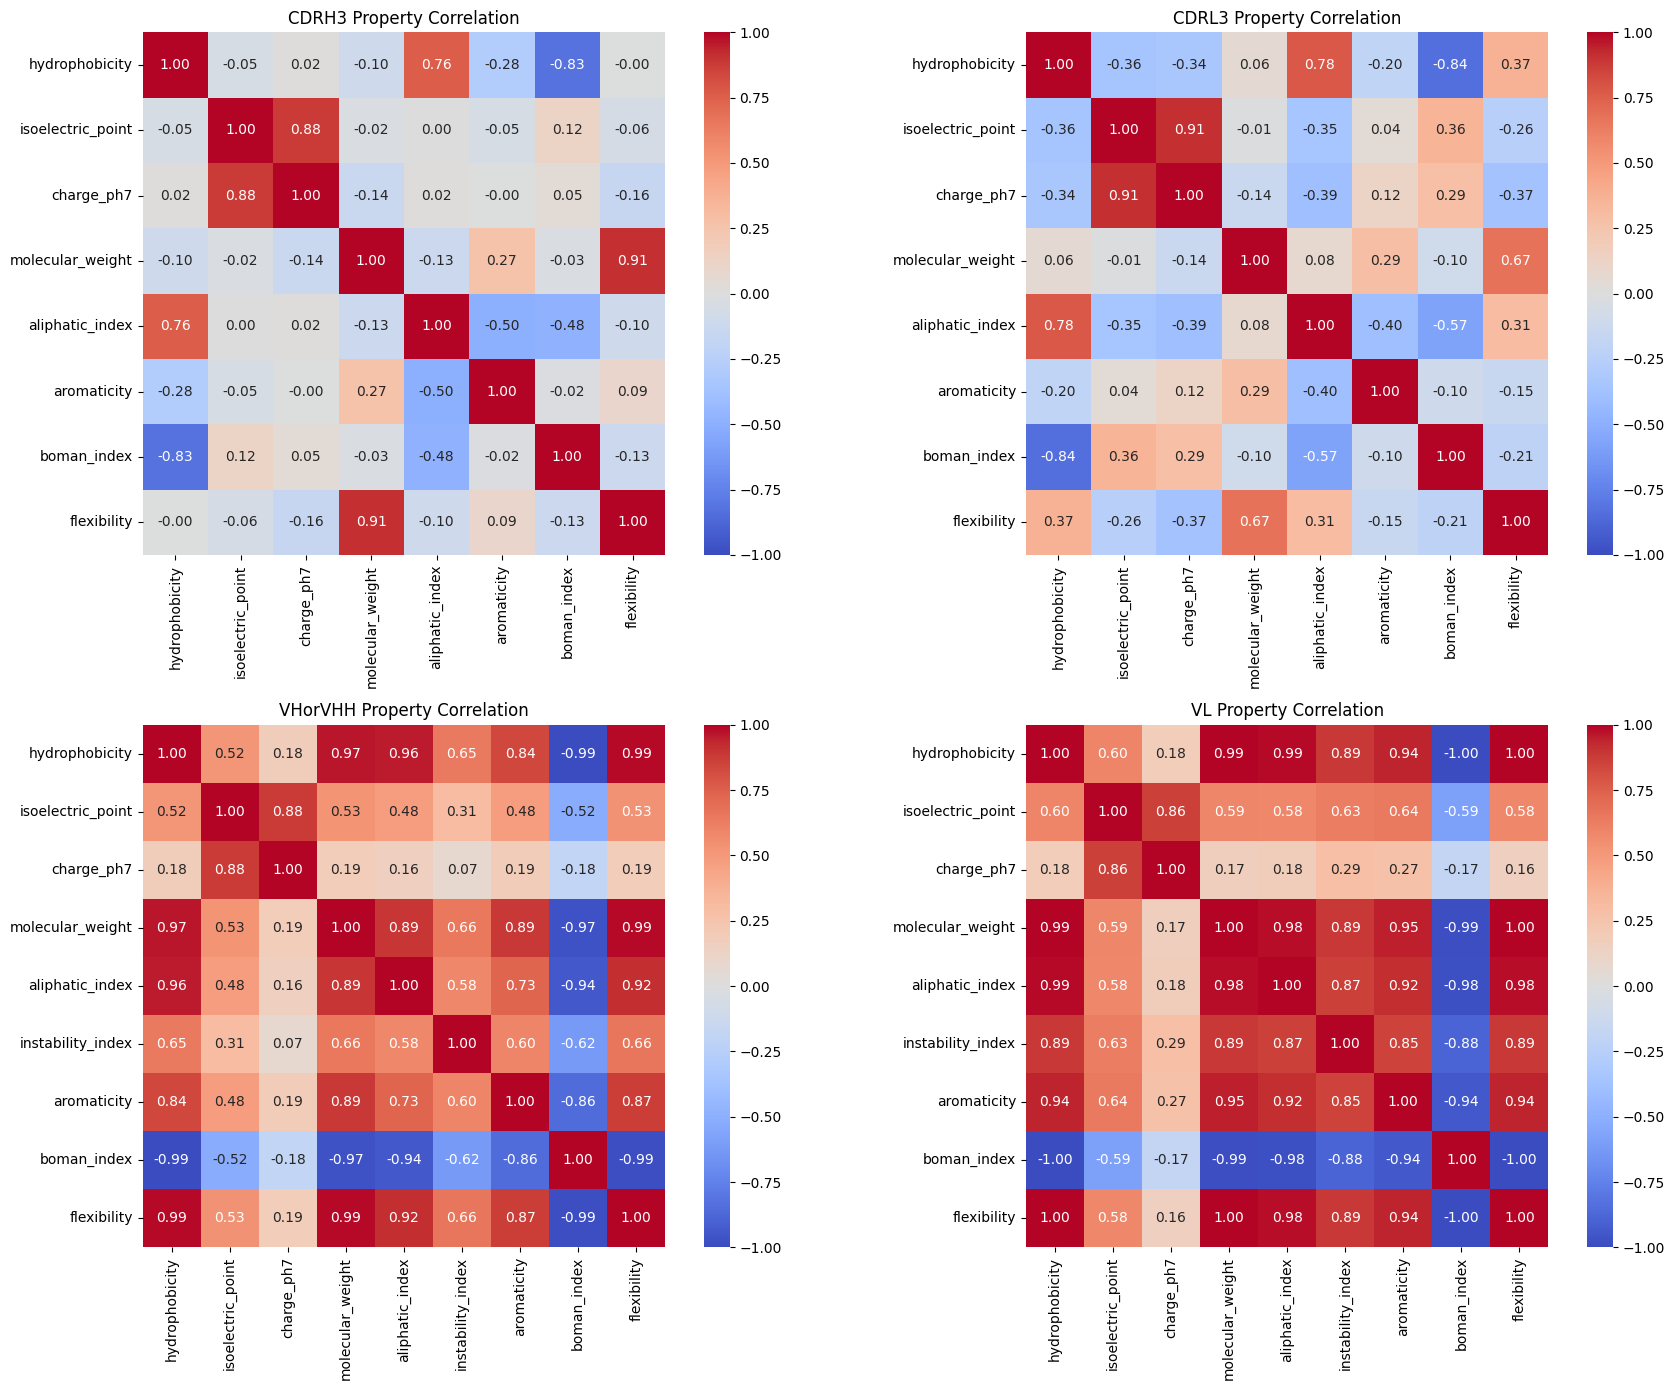

In [ ]:
regions = ["CDRH3", "CDRL3", "VHorVHH", "VL"]

property_suffixes = {
    "hydrophobicity": ["hydrophobicity"],
    "isoelectric_point": ["isoelectric_point"],
    "charge_ph7": ["charge_ph7"],
    "molecular_weight": ["molecular_weight"],
    "aliphatic_index": ["aliphatic_index"],
    "instability_index": ["instability_index"],
    "aromaticity": ["aromaticity"],
    "boman_index": ["boman_index"],
    "flexibility": ["flexibility"],
}

def resolve_region_property_columns(df, region, suffix_map):
    selected = {}
    missing = []

    for canonical_name, candidates in suffix_map.items():
        matched_col = None
        for suffix in candidates:
            col = f"{region}_{suffix}"
            if col in df.columns:
                matched_col = col
                break

        if matched_col is None:
            missing.append(canonical_name)
        else:
            selected[canonical_name] = matched_col

    region_df = df[list(selected.values())].rename(columns={v: k for k, v in selected.items()})
    return region_df, selected, missing

region_property_dfs = {}
region_corr = {}
region_column_map = {}
region_missing_props = {}

for region in regions:
    region_df, selected_cols, missing_props = resolve_region_property_columns(
        df_cleaned, region, property_suffixes
    )

    region_property_dfs[region] = region_df
    region_column_map[region] = selected_cols
    region_missing_props[region] = missing_props
    region_corr[region] = region_df.corr(numeric_only=True)

    print(f"\n{region}")
    print(f"- Available properties: {list(selected_cols.keys())}")
    print(f"- Missing properties: {missing_props if missing_props else 'None'}")
    print(f"- Shape: {region_df.shape}")


cdrh3_properties = region_property_dfs["CDRH3"]
cdrl3_properties = region_property_dfs["CDRL3"]
vhorvhh_properties = region_property_dfs["VHorVHH"]
vl_properties = region_property_dfs["VL"]

# Display correlation matrices in a 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
for ax, region in zip(axes.flatten(), regions):
    sns.heatmap(
        region_corr[region],
        ax=ax,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        square=True,
        cbar=True,
    )
    ax.set_title(f"{region} Property Correlation")

plt.tight_layout()
plt.show()

From these four correlation matrices, we can find the following commonalities:

- Aliphatic index and hydrophobicity have a strongly positive correlation (+0.76 ~ +0.99)
- Hydrophobicity and Boman index have a strongly negative correlation (-0.83 ~ -1.00)

- Charge at ph7 and isoelectric point have a strongly positive correlation (+0.86 ~ +0.91)
- Flexibility and molecular weight have a moderate to strongly positive correlation (+0.67 for CDRL3, +0.91 ~ +0.99 for the rest - CDRH3, VL & VHorVHH)

In an ML model, features with strong correlation (whether positive or negative) should as much as possible not be included together as they introduce **Multicollinearity**, that is, confusion about which feature is actually driving the prediction because they are telling the exact same story.

To combat **Multicollinearity**, when creating an ML model, as much as possible, strongly correlated features should not be combined together. Thus, the following features will be selected:

**CDR Regions**
- Aliphatic index
- Boman index
- Isoelectric point
- Molecular weight
- Aromaticity

**VHorVHH & VL**
- Molecular weight
- Isoelectric point

In **VHorVHH & VL**, molecular weight is strongly correlated to almost every single property minus charge-related properties. 